## Part A: Data Handling Basics

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

# Display plots inside notebook
%matplotlib inline

sns.set_style("whitegrid")

In [3]:
df = pd.read_excel("loan_data.xlsx")

print("First 5 Records:")
display(df.head())

print("\nDataset Information:")
df.info()

First 5 Records:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001,Male,Yes,0,Graduate,No,5849,0,128,360,1,Urban,Y
1,LP002,Male,Yes,1,Graduate,No,4583,1508,128,360,1,Rural,N
2,LP003,Male,Yes,0,Graduate,Yes,3000,0,66,360,1,Urban,Y
3,LP004,Male,No,0,Not Graduate,No,2583,2358,120,360,1,Urban,Y
4,LP005,Female,Yes,0,Graduate,No,6000,0,141,360,1,Semiurban,Y



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Loan_ID            15 non-null     str   
 1   Gender             15 non-null     str   
 2   Married            15 non-null     str   
 3   Dependents         15 non-null     object
 4   Education          15 non-null     str   
 5   Self_Employed      15 non-null     str   
 6   ApplicantIncome    15 non-null     int64 
 7   CoapplicantIncome  15 non-null     int64 
 8   LoanAmount         15 non-null     int64 
 9   Loan_Amount_Term   15 non-null     int64 
 10  Credit_History     15 non-null     int64 
 11  Property_Area      15 non-null     str   
 12  Loan_Status        15 non-null     str   
dtypes: int64(5), object(1), str(7)
memory usage: 1.7+ KB


## Part B: Financial Analytics

In [17]:
url = "https://raw.githubusercontent.com/dphi-official/Datasets/master/Loan_Data/loan_train.csv"

loan_df = pd.read_csv(url)

loan_df.head()

,Unnamed: 0,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,LP002305,Female,No,0,Graduate,No,4547,0.0,115.0,360.0,1.0,Semiurban,1
1,1,LP001715,Male,Yes,3+,Not Graduate,Yes,5703,0.0,130.0,360.0,1.0,Rural,1
2,2,LP002086,Female,Yes,0,Graduate,No,4333,2451.0,110.0,360.0,1.0,Urban,0
3,3,LP001136,Male,Yes,0,Not Graduate,Yes,4695,0.0,96.0,NaN,1.0,Urban,1
4,4,LP002529,Male,Yes,2,Graduate,No,6700,1750.0,230.0,300.0,1.0,Semiurban,1


In [18]:
print("Dataset Shape:", loan_df.shape)
loan_df.info()

Dataset Shape: (491, 14)
<class 'pandas.DataFrame'>
RangeIndex: 491 entries, 0 to 490
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         491 non-null    int64  
 1   Loan_ID            491 non-null    str    
 2   Gender             481 non-null    str    
 3   Married            490 non-null    str    
 4   Dependents         482 non-null    str    
 5   Education          491 non-null    str    
 6   Self_Employed      462 non-null    str    
 7   ApplicantIncome    491 non-null    int64  
 8   CoapplicantIncome  491 non-null    float64
 9   LoanAmount         475 non-null    float64
 10  Loan_Amount_Term   478 non-null    float64
 11  Credit_History     448 non-null    float64
 12  Property_Area      491 non-null    str    
 13  Loan_Status        491 non-null    int64  
dtypes: float64(4), int64(3), str(7)
memory usage: 53.8 KB


In [19]:
# 1) drop loan id

loan_df.drop(columns=["Loan_ID"], errors="ignore", inplace=True)
loan_df.head()

,Unnamed: 0,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,Female,No,0,Graduate,No,4547,0.0,115.0,360.0,1.0,Semiurban,1
1,1,Male,Yes,3+,Not Graduate,Yes,5703,0.0,130.0,360.0,1.0,Rural,1
2,2,Female,Yes,0,Graduate,No,4333,2451.0,110.0,360.0,1.0,Urban,0
3,3,Male,Yes,0,Not Graduate,Yes,4695,0.0,96.0,NaN,1.0,Urban,1
4,4,Male,Yes,2,Graduate,No,6700,1750.0,230.0,300.0,1.0,Semiurban,1


In [20]:
# 2) identify categorical columns

categorical_cols = loan_df.select_dtypes(
    include=['object', 'string']
).columns.tolist()

print(categorical_cols)

['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']


In [22]:
# 3) Handle missing values

numeric_cols = loan_df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    missing_count = loan_df[col].isna().sum()

    if missing_count > 0:
        mean_value = loan_df[col].mean()

        loan_df[col] = loan_df[col].fillna(mean_value)

        print(
            f"Column '{col}': "
            f"replaced {missing_count} missing value(s) "
            f"with mean = {mean_value:.2f}"
        )
    else:
        print(f"Column '{col}': no missing values found")

print("""
Replacing missing values with the mean is better than dropping rows
because dropping records reduces the amount of available data and may
remove useful information. Mean imputation preserves the dataset size
while providing a reasonable estimate for missing numerical values.
""")

Column 'Unnamed: 0': no missing values found
Column 'ApplicantIncome': no missing values found
Column 'CoapplicantIncome': no missing values found
Column 'LoanAmount': replaced 16 missing value(s) with mean = 145.01
Column 'Loan_Amount_Term': replaced 13 missing value(s) with mean = 341.30
Column 'Credit_History': replaced 43 missing value(s) with mean = 0.85
Column 'Loan_Status': no missing values found

Replacing missing values with the mean is better than dropping rows
because dropping records reduces the amount of available data and may
remove useful information. Mean imputation preserves the dataset size
while providing a reasonable estimate for missing numerical values.



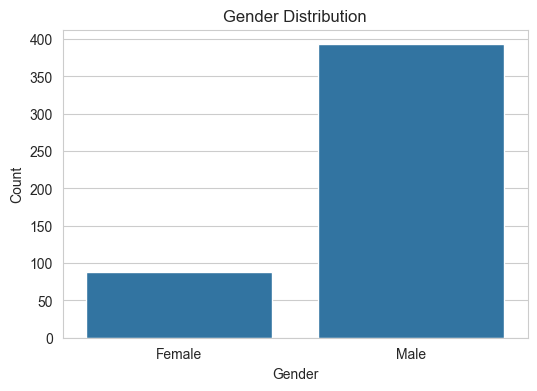

In [23]:
# 4) Create bar chart

plt.figure(figsize=(6,4))

sns.countplot(x='Gender', data=loan_df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

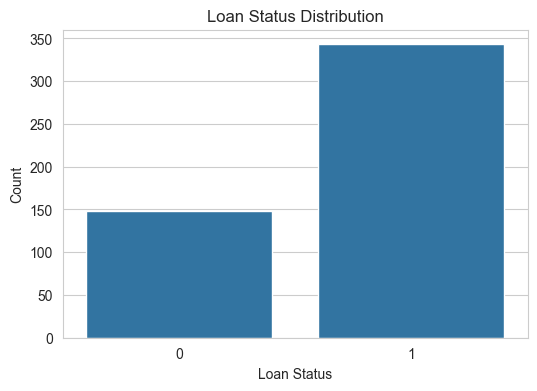

In [24]:
plt.figure(figsize=(6,4))

sns.countplot(x='Loan_Status', data=loan_df)

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()

In [26]:
# 5) Interpretation

print("""
Interpretation:

1. The Gender chart shows the distribution of loan applicants by gender.

2. The Loan Status chart shows how many applications were approved
   versus rejected.

3. If approved loans significantly outnumber rejected loans,
   it suggests that a large proportion of applicants satisfy
   the eligibility criteria.

4. Factors such as applicant income, co-applicant income,
   loan amount, education level, and credit history are likely
   to influence loan approval decisions.
""")


Interpretation:

1. The Gender chart shows the distribution of loan applicants by gender.

2. The Loan Status chart shows how many applications were approved
   versus rejected.

3. If approved loans significantly outnumber rejected loans,
   it suggests that a large proportion of applicants satisfy
   the eligibility criteria.

4. Factors such as applicant income, co-applicant income,
   loan amount, education level, and credit history are likely
   to influence loan approval decisions.



## Part C: Healthcare Analytics

In [28]:
import pandas as pd

url = "https://raw.githubusercontent.com/ksatola/Medical-Appointments-No-Shows/master/noshowappointments-kagglev2-may-2016.csv"

health_df = pd.read_csv(url)

health_df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [29]:
# 1) 1.	Drop identifier/date columns: PatientID, AppointmentID, ScheduledDay, AppointmentDay.

columns_to_drop = [
    "PatientID",
    "AppointmentID",
    "ScheduledDay",
    "AppointmentDay"
]

health_df.drop(
    columns=columns_to_drop,
    errors="ignore",
    inplace=True
)

health_df.head()

,PatientId,Gender,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,F,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,M,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,F,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,F,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,F,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [31]:
# 2) Convert categorical columns (Gender, Neighbourhood, No-show) into numeric using Label Encoding.

categorical_cols = health_df.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Categorical Columns:")
print(categorical_cols)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in categorical_cols:
    health_df[col] = le.fit_transform(
        health_df[col].astype(str)
    )

    print(f"Encoded column: {col}")

Categorical Columns:
['Gender', 'Neighbourhood', 'No-show']
Encoded column: Gender
Encoded column: Neighbourhood
Encoded column: No-show


In [33]:
# 3) Generate summary statistics
summary_cols = [
    "Age",
    "Hipertension",
    "Diabetes",
    "Alcoholism",
    "Handcap"
]

health_df[summary_cols].describe()

,Age,Hipertension,Diabetes,Alcoholism,Handcap
count,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,37.088874,0.197246,0.071865,0.030400,0.022248
std,23.110205,0.397921,0.258265,0.171686,0.161543
min,-1.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,0.000000,0.000000,0.000000,0.000000
50%,37.000000,0.000000,0.000000,0.000000,0.000000
75%,55.000000,0.000000,0.000000,0.000000,0.000000
max,115.000000,1.000000,1.000000,1.000000,4.000000


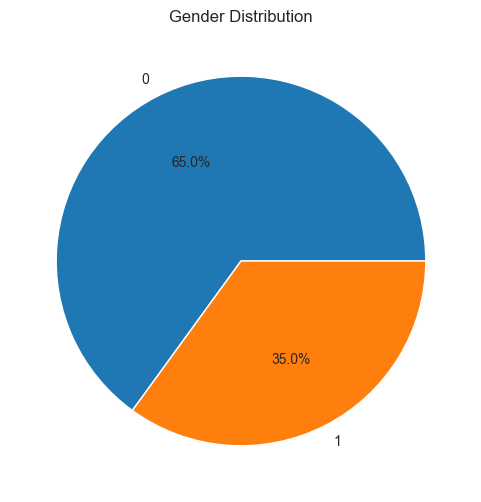

In [42]:
# 4) Visualisations

# Pie chart showing gender distribution of patients.

gender_counts = health_df["Gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.show()

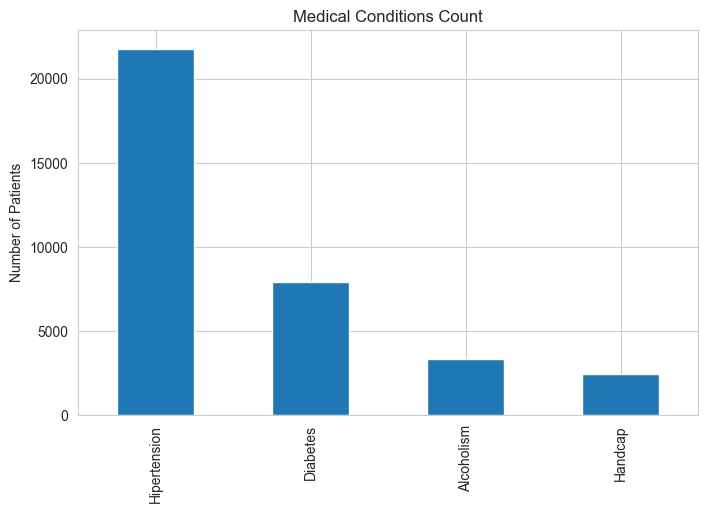

In [43]:
# Bar chart comparing counts of patients with Hypertension, Diabetes, Alcoholism, and Handicap.

conditions = [
    "Hipertension",
    "Diabetes",
    "Alcoholism",
    "Handcap"
]

condition_counts = health_df[conditions].sum()

plt.figure(figsize=(8,5))

condition_counts.plot(kind="bar")

plt.title("Medical Conditions Count")
plt.ylabel("Number of Patients")

plt.show()

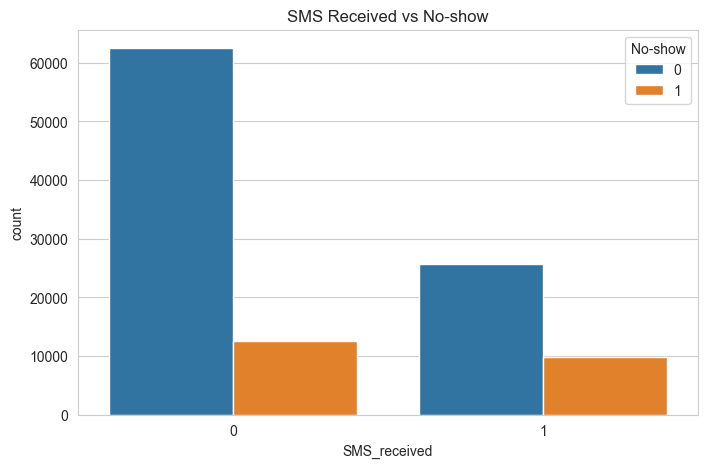

In [44]:
# Bar chart of SMS_received vs No-show.

plt.figure(figsize=(8,5))

sns.countplot(
    x="SMS_received",
    hue="No-show",
    data=health_df
)

plt.title("SMS Received vs No-show")

plt.show()

In [45]:
# 5) Interpretation

print("""
Healthcare Attendance Insights

1. The gender distribution chart shows the proportion
   of male and female patients in the dataset.

2. The medical conditions chart indicates the prevalence
   of Hypertension, Diabetes, Alcoholism, and Handicap
   among patients.

3. The SMS_received vs No-show chart helps identify
   whether appointment reminders influence attendance.

4. If patients receiving SMS reminders show lower
   no-show rates, reminder systems may improve
   appointment adherence.

5. Hospitals can use these insights to improve
   scheduling efficiency and reduce missed appointments.
""")


Healthcare Attendance Insights

1. The gender distribution chart shows the proportion
   of male and female patients in the dataset.

2. The medical conditions chart indicates the prevalence
   of Hypertension, Diabetes, Alcoholism, and Handicap
   among patients.

3. The SMS_received vs No-show chart helps identify
   whether appointment reminders influence attendance.

4. If patients receiving SMS reminders show lower
   no-show rates, reminder systems may improve
   appointment adherence.

5. Hospitals can use these insights to improve
   scheduling efficiency and reduce missed appointments.



## Part D: Reflection

## 1. Why is handling missing values important before visualization or analysis?

Handling missing values is important because missing data can lead to inaccurate analysis, misleading visualizations, and incorrect conclusions. By replacing or handling missing values appropriately, we ensure that the dataset remains complete and that statistical calculations and visual representations are more reliable.

---

## 2. What role does Label Encoding play in preparing categorical data?

Label Encoding converts categorical values (such as "Male", "Female", "Yes", and "No") into numerical values that can be processed by analytical and machine learning algorithms. This allows categorical information to be included in calculations, visualizations, and predictive models.

---

## 3. From the visualizations, what real-world insights can you derive?

### Banks (Loan Eligibility)

- Loan approval decisions are influenced by factors such as income, credit history, education, and employment status.
- Applicants with stronger financial profiles and positive credit histories are generally more likely to receive loan approval.
- Analyzing applicant characteristics helps banks assess risk and make more informed lending decisions.
- Understanding approval patterns can help banks improve their loan evaluation processes and customer targeting strategies.

### Hospitals (Patient Attendance)

- Patient attendance patterns can be analyzed using demographic and medical information.
- SMS reminders may help reduce the number of missed appointments and improve attendance rates.
- Common health conditions such as hypertension and diabetes can help hospitals understand the needs of their patient population.
- These insights can help hospitals optimize scheduling, reduce no-shows, and improve overall healthcare service delivery.